In [1]:
!python nopants_train.py --nepoch 600 --save_path 'results/yolov3_07' --ctrl 50 --arch "yolov3" --seed_type variable --clamp_shift 0.01 --loss_type max_iou --seed_ratio 0.7 --device 'cuda'

Version 2.0
Train info: Namespace(device='cuda', lr=0.001, lr_seed=0.01, nepoch=600, checkpoints=0, batch_size=4, save_path='results/yolov3_07', alpha=10, tv_loss=0, lr_decay=2, lr_decay_seed=2, blur=1, like=1, ctrl=50.0, num_points_tshirt=60, num_points_trouser=60, arch='yolov3', cdist=0, seed_type='variable', rd_num=200, clamp_shift=0.01, resample_type=None, seed_temp=1.0, seed_opt='adam', tps2d_range_t=50.0, tps2d_range_r=0.1, tps3d_range=0.15, disable_tps2d=False, disable_tps3d=False, disable_test_tps2d=False, disable_test_tps3d=False, seed_ratio=0.7, loss_type='max_iou', test=False, test_iou=0.1, test_nms_thresh=1.0, test_mode='person', test_suffix='', train_iou=0.01, anneal=False, anneal_init=5.0, anneal_alpha=3.0)
One training epoch has 376 images
One test epoch has 130 images
/home/cynthia/miniforge3/envs/camo/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered in

In [65]:
from nopants_train import *
import argparse
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
parser = argparse.ArgumentParser(description='PyTorch Training')
parser.add_argument('--device', default='cuda:1', help='')
parser.add_argument('--lr', type=float, default=0.001, help='')
parser.add_argument('--lr_seed', type=float, default=0.01, help='')
parser.add_argument('--nepoch', type=int, default=600, help='')
parser.add_argument('--checkpoints', type=int, default=0, help='')
parser.add_argument('--batch_size', type=int, default=4, help='')
parser.add_argument('--save_path', default='results/', help='')
parser.add_argument("--alpha", type=float, default=10, help='')
parser.add_argument("--tv_loss", type=float, default=0, help='')
parser.add_argument("--lr_decay", type=float, default=2, help='')
parser.add_argument("--lr_decay_seed", type=float, default=2, help='')
parser.add_argument("--blur", type=float, default=1, help='')
parser.add_argument("--like", type=float, default=1, help='')
parser.add_argument("--ctrl", type=float, default=1, help='')
parser.add_argument("--num_points_tshirt", type=int, default=60, help='')
parser.add_argument("--num_points_trouser", type=int, default=60, help='')
parser.add_argument("--arch", type=str, default="rcnn")
parser.add_argument("--cdist", type=float, default=0, help='')
parser.add_argument("--seed_type", default='fixed', help='fixed, random, variable, langevin')
parser.add_argument("--rd_num", type=int, default=200, help='')
parser.add_argument("--clamp_shift", type=float, default=0, help='')
parser.add_argument("--resample_type", default=None, help='')
parser.add_argument("--seed_temp", type=float, default=1.0, help='')
parser.add_argument("--seed_opt", default='adam', help='')
parser.add_argument("--tps2d_range_t", type=float, default=50.0, help='')
parser.add_argument("--tps2d_range_r", type=float, default=0.1, help='')
parser.add_argument("--tps3d_range", type=float, default=0.15, help='')
parser.add_argument("--disable_tps2d", default=False, action='store_true', help='')
parser.add_argument("--disable_tps3d", default=False, action='store_true', help='')
parser.add_argument("--disable_test_tps2d", default=False, action='store_true', help='')
parser.add_argument("--disable_test_tps3d", default=False, action='store_true', help='')
parser.add_argument("--seed_ratio", default=1.0, type=float, help='The ratio of trainable part when seed type is variable')
parser.add_argument("--loss_type", default='max_iou', help='max_iou, max_conf, softplus_max, softplus_sum')
parser.add_argument("--loss_ssim", default=0.3, help='constant dictating weight of SSIM loss to force texture similarity to image')
parser.add_argument("--test", default=False, action='store_true', help='')
parser.add_argument("--test_iou", type=float, default=0.1, help='')
parser.add_argument("--test_nms_thresh", type=float, default=1.0, help='')
parser.add_argument("--test_mode", default='person', help='person, all')
parser.add_argument("--test_suffix", default='', help='')
parser.add_argument("--train_iou", type=float, default=0.01, help='')
parser.add_argument("--anneal", default=False, action='store_true', help='')
parser.add_argument("--anneal_init", type=float, default=5.0, help='')
parser.add_argument("--anneal_alpha", type=float, default=3.0, help='')

args = parser.parse_args(args = "--nepoch 100 --save_path results/yolov3_07 --ctrl 50 --arch yolov3 --seed_type variable --clamp_shift 0.01 --loss_type max_iou --seed_ratio 0.7 --device cuda".split())
assert args.seed_type in ['fixed', 'random', 'variable', 'langevin']

torch.manual_seed(123)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

# print("Train info:", args)
# trainer = PatchTrainer(args)
# if not args.test:
#     trainer.train()
# else:
#     epoch = args.checkpoints - 1
#     trainer.load_weights(args.save_path, epoch)
#     trainer.update_mesh(type='determinate')
#     precision, recall, avg, confs, thetas = trainer.test(conf_thresh=0.01, iou_thresh=args.test_iou, angle_sample=37, use_tps2d=not args.disable_test_tps2d, use_tps3d=not args.disable_test_tps3d, mode=args.test_mode)
#     info = [precision, recall, avg, confs]
#     path = args.save_path + '/' + str(epoch) + 'test_results_tps'
#     path = path + '_iou' + str(args.test_iou).replace('.', '') + '_' + args.test_mode + args.test_suffix
#     path = path + '.npz'
#     np.savez(path, thetas=thetas, info=info)

One training epoch has 376 images
One test epoch has 130 images
max range is 19.587, max number of the bins is 461


  0%|                                                                                                                                     | 0/100 [00:00<?, ?it/s]

######################################
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')
  EPOCH NR:  0
EPOCH LOSS:  1.0774667123530774
  DET LOSS:  0.9227797522189769
 MEAN PROB:  0.9227797522189769
   TV LOSS:  0.0
 CTRL LOSS:  0.005597711560573984
 SEED LOSS:  0.0
 SSIM LOSS:  0.7053031442647285
EPOCH TIME:  30.63226556777954


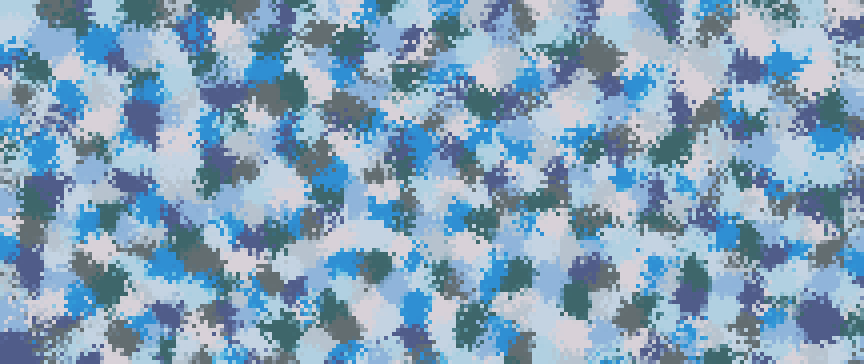

  1%|█▎                                                                                                                           | 1/100 [00:30<50:34, 30.65s/it]

######################################


  2%|██▌                                                                                                                          | 2/100 [01:00<49:25, 30.26s/it]

  EPOCH NR:  1
EPOCH LOSS:  0.9156273077142999
  DET LOSS:  0.9135129096660208
 MEAN PROB:  0.9135129096660208
   TV LOSS:  0.0
 CTRL LOSS:  0.0024302432590976673
 SEED LOSS:  0.0
 SSIM LOSS:  0.702763854506168
EPOCH TIME:  30.006112337112427
######################################


  3%|███▊                                                                                                                         | 3/100 [01:31<49:32, 30.65s/it]

  EPOCH NR:  2
EPOCH LOSS:  0.8837719502601218
  DET LOSS:  0.9387259293109813
 MEAN PROB:  0.9387259293109813
   TV LOSS:  0.0
 CTRL LOSS:  0.0018344118477816277
 SEED LOSS:  0.0
 SSIM LOSS:  0.698178766572729
EPOCH TIME:  31.109924793243408
######################################


  4%|█████                                                                                                                        | 4/100 [02:02<49:09, 30.73s/it]

  EPOCH NR:  3
EPOCH LOSS:  0.8657566708453158
  DET LOSS:  0.92502461532329
 MEAN PROB:  0.92502461532329
   TV LOSS:  0.0
 CTRL LOSS:  0.0015419390488495219
 SEED LOSS:  0.0
 SSIM LOSS:  0.6961572541201368
EPOCH TIME:  30.8450129032135
######################################
  EPOCH NR:  4
EPOCH LOSS:  0.8526913770969878
  DET LOSS:  0.9128433725935348
 MEAN PROB:  0.9128433725935348
   TV LOSS:  0.0
 CTRL LOSS:  0.0013780165859993468
 SEED LOSS:  0.0
 SSIM LOSS:  0.692506212186306
EPOCH TIME:  31.20327067375183


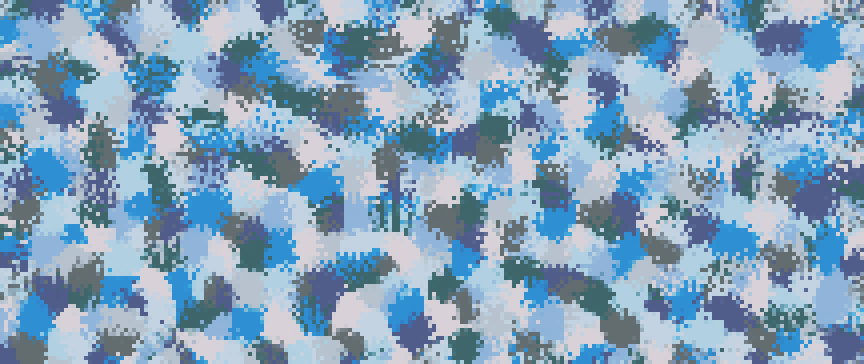

  5%|██████▎                                                                                                                      | 5/100 [02:33<48:55, 30.90s/it]

######################################


  6%|███████▌                                                                                                                     | 6/100 [03:04<48:26, 30.92s/it]

  EPOCH NR:  5
EPOCH LOSS:  0.8441512140821903
  DET LOSS:  0.8986290027486518
 MEAN PROB:  0.8986290027486518
   TV LOSS:  0.0
 CTRL LOSS:  0.0013017132680149788
 SEED LOSS:  0.0
 SSIM LOSS:  0.6892026529667226
EPOCH TIME:  30.963254928588867
######################################


  7%|████████▊                                                                                                                    | 7/100 [03:35<47:48, 30.85s/it]

  EPOCH NR:  6
EPOCH LOSS:  0.8388789543446075
  DET LOSS:  0.9114910154900653
 MEAN PROB:  0.9114910154900653
   TV LOSS:  0.0
 CTRL LOSS:  0.0012183526649754098
 SEED LOSS:  0.0
 SSIM LOSS:  0.686812217882339
EPOCH TIME:  30.705363273620605
######################################


  8%|██████████                                                                                                                   | 8/100 [04:06<47:24, 30.92s/it]

  EPOCH NR:  7
EPOCH LOSS:  0.8327629166714688
  DET LOSS:  0.9102624293337477
 MEAN PROB:  0.9102624293337477
   TV LOSS:  0.0
 CTRL LOSS:  0.001171208383079539
 SEED LOSS:  0.0
 SSIM LOSS:  0.6831762530702226
EPOCH TIME:  31.060884952545166
######################################


  9%|███████████▎                                                                                                                 | 9/100 [04:37<47:01, 31.01s/it]

  EPOCH NR:  8
EPOCH LOSS:  0.8291871782313002
  DET LOSS:  0.8525789603590965
 MEAN PROB:  0.8525789603590965
   TV LOSS:  0.0
 CTRL LOSS:  0.0011202039078195044
 SEED LOSS:  0.0
 SSIM LOSS:  0.6879190802574158
EPOCH TIME:  31.21135687828064
######################################
  EPOCH NR:  9
EPOCH LOSS:  0.8379491180815595
  DET LOSS:  0.9081610314389492
 MEAN PROB:  0.9081610314389492
   TV LOSS:  0.0
 CTRL LOSS:  0.0010768193553419823
 SEED LOSS:  0.0
 SSIM LOSS:  0.6932920426764386
EPOCH TIME:  30.87273406982422


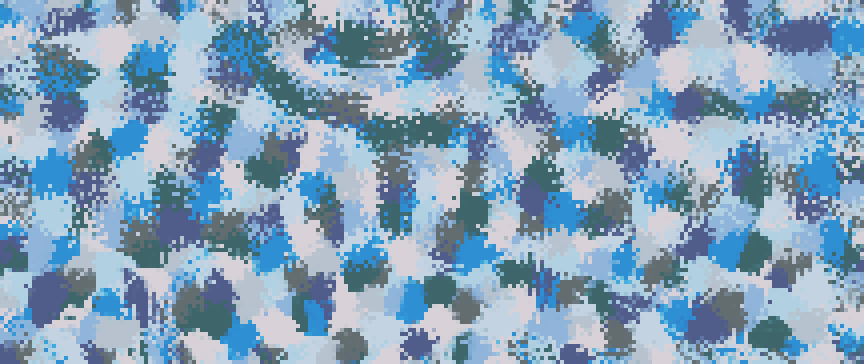

 10%|████████████▍                                                                                                               | 10/100 [05:08<46:27, 30.97s/it]

######################################


 11%|█████████████▋                                                                                                              | 11/100 [05:38<45:34, 30.73s/it]

  EPOCH NR:  10
EPOCH LOSS:  0.8372323538394685
  DET LOSS:  0.9227871729972514
 MEAN PROB:  0.9227871729972514
   TV LOSS:  0.0
 CTRL LOSS:  0.001069412408198448
 SEED LOSS:  0.0
 SSIM LOSS:  0.6914830134904131
EPOCH TIME:  30.196558237075806
######################################


 12%|██████████████▉                                                                                                             | 12/100 [06:09<44:52, 30.60s/it]

  EPOCH NR:  11
EPOCH LOSS:  0.8341357403613151
  DET LOSS:  0.9013510777595195
 MEAN PROB:  0.9013510777595195
   TV LOSS:  0.0
 CTRL LOSS:  0.0010294142040483496
 SEED LOSS:  0.0
 SSIM LOSS:  0.6925299202508115
EPOCH TIME:  30.296144008636475
######################################


 13%|████████████████                                                                                                            | 13/100 [06:40<44:33, 30.73s/it]

  EPOCH NR:  12
EPOCH LOSS:  0.8288747097583528
  DET LOSS:  0.8907797609237914
 MEAN PROB:  0.8907797609237914
   TV LOSS:  0.0
 CTRL LOSS:  0.0010174759366410845
 SEED LOSS:  0.0
 SSIM LOSS:  0.6889229334415273
EPOCH TIME:  31.020326137542725
######################################


 14%|█████████████████▎                                                                                                          | 14/100 [07:11<44:06, 30.77s/it]

  EPOCH NR:  13
EPOCH LOSS:  0.8296780573560837
  DET LOSS:  0.9030893051877935
 MEAN PROB:  0.9030893051877935
   TV LOSS:  0.0
 CTRL LOSS:  0.000991631200180409
 SEED LOSS:  0.0
 SSIM LOSS:  0.6897875688811566
EPOCH TIME:  30.882664680480957
######################################
  EPOCH NR:  14
EPOCH LOSS:  0.8245750012549948
  DET LOSS:  0.9117572326609429
 MEAN PROB:  0.9117572326609429
   TV LOSS:  0.0
 CTRL LOSS:  0.0009809653770099294
 SEED LOSS:  0.0
 SSIM LOSS:  0.6843510089402504
EPOCH TIME:  30.58390760421753


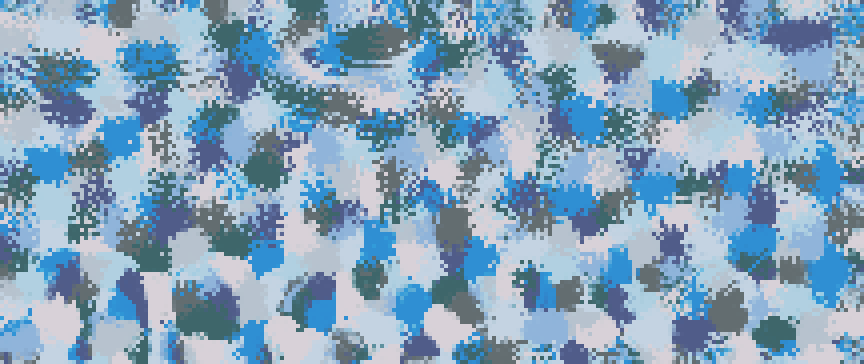

 15%|██████████████████▌                                                                                                         | 15/100 [07:41<43:31, 30.72s/it]

######################################


 16%|███████████████████▊                                                                                                        | 16/100 [08:12<43:00, 30.72s/it]

  EPOCH NR:  15
EPOCH LOSS:  0.8236723415395046
  DET LOSS:  0.888677364651193
 MEAN PROB:  0.888677364651193
   TV LOSS:  0.0
 CTRL LOSS:  0.0009665312245488167
 SEED LOSS:  0.0
 SSIM LOSS:  0.6864780498311874
EPOCH TIME:  30.731407642364502
######################################


 17%|█████████████████████                                                                                                       | 17/100 [08:43<42:29, 30.71s/it]

  EPOCH NR:  16
EPOCH LOSS:  0.8241572849293972
  DET LOSS:  0.8525767281968543
 MEAN PROB:  0.8525767281968543
   TV LOSS:  0.0
 CTRL LOSS:  0.0009776353043444612
 SEED LOSS:  0.0
 SSIM LOSS:  0.6900178501580624
EPOCH TIME:  30.695451974868774
######################################


 18%|██████████████████████▎                                                                                                     | 18/100 [09:13<41:48, 30.59s/it]

  EPOCH NR:  17
EPOCH LOSS:  0.8280519354850688
  DET LOSS:  0.8872576660298287
 MEAN PROB:  0.8872576660298287
   TV LOSS:  0.0
 CTRL LOSS:  0.0009680255018967263
 SEED LOSS:  0.0
 SSIM LOSS:  0.6909248876444837
EPOCH TIME:  30.301676273345947
######################################


 19%|███████████████████████▌                                                                                                    | 19/100 [09:43<41:10, 30.50s/it]

  EPOCH NR:  18
EPOCH LOSS:  0.824351485105271
  DET LOSS:  0.8726996662134819
 MEAN PROB:  0.8726996662134819
   TV LOSS:  0.0
 CTRL LOSS:  0.000957998070628085
 SEED LOSS:  0.0
 SSIM LOSS:  0.6891816077714271
EPOCH TIME:  30.308418035507202
######################################
  EPOCH NR:  19
EPOCH LOSS:  0.8292553970154296
  DET LOSS:  0.8792323577911296
 MEAN PROB:  0.8792323577911296
   TV LOSS:  0.0
 CTRL LOSS:  0.0009367730904449808
 SEED LOSS:  0.0
 SSIM LOSS:  0.6944935004761879
EPOCH TIME:  30.615145444869995


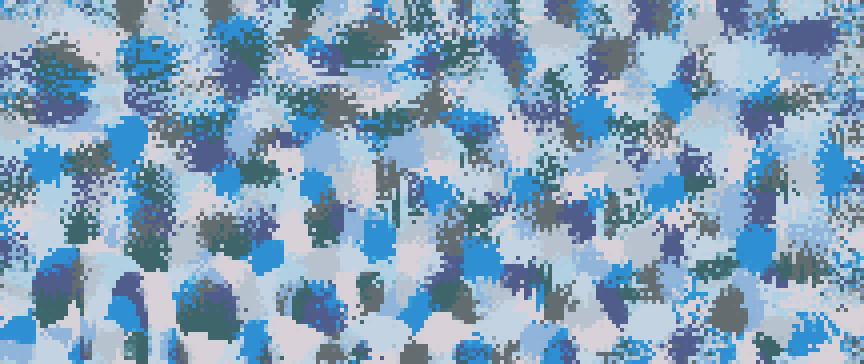

 20%|████████████████████████▊                                                                                                   | 20/100 [10:14<40:43, 30.54s/it]

######################################


 21%|██████████████████████████                                                                                                  | 21/100 [10:44<40:06, 30.46s/it]

  EPOCH NR:  20
EPOCH LOSS:  0.8280664707751985
  DET LOSS:  0.8588013059281289
 MEAN PROB:  0.8588013059281289
   TV LOSS:  0.0
 CTRL LOSS:  0.0009377396447544402
 SEED LOSS:  0.0
 SSIM LOSS:  0.695299358126965
EPOCH TIME:  30.274441480636597
######################################


 22%|███████████████████████████▎                                                                                                | 22/100 [11:15<39:40, 30.52s/it]

  EPOCH NR:  21
EPOCH LOSS:  0.8282001037546929
  DET LOSS:  0.8662306501510295
 MEAN PROB:  0.8662306501510295
   TV LOSS:  0.0
 CTRL LOSS:  0.000921845000157965
 SEED LOSS:  0.0
 SSIM LOSS:  0.6954847853234474
EPOCH TIME:  30.671403169631958
######################################


 23%|████████████████████████████▌                                                                                               | 23/100 [11:45<39:11, 30.54s/it]

  EPOCH NR:  22
EPOCH LOSS:  0.8263556120243478
  DET LOSS:  0.8454130073177054
 MEAN PROB:  0.8454130073177054
   TV LOSS:  0.0
 CTRL LOSS:  0.0009146066818465578
 SEED LOSS:  0.0
 SSIM LOSS:  0.696083980354857
EPOCH TIME:  30.596267700195312
######################################


 24%|█████████████████████████████▊                                                                                              | 24/100 [12:16<38:36, 30.48s/it]

  EPOCH NR:  23
EPOCH LOSS:  0.8243781645247277
  DET LOSS:  0.8307212134625049
 MEAN PROB:  0.8307212134625049
   TV LOSS:  0.0
 CTRL LOSS:  0.000928608978048284
 SEED LOSS:  0.0
 SSIM LOSS:  0.6948755893935549
EPOCH TIME:  30.317498683929443
######################################
  EPOCH NR:  24
EPOCH LOSS:  0.8246786645118226
  DET LOSS:  0.829554556215063
 MEAN PROB:  0.829554556215063
   TV LOSS:  0.0
 CTRL LOSS:  0.0009161223399829357
 SEED LOSS:  0.0
 SSIM LOSS:  0.6959170867153939
EPOCH TIME:  30.013617515563965


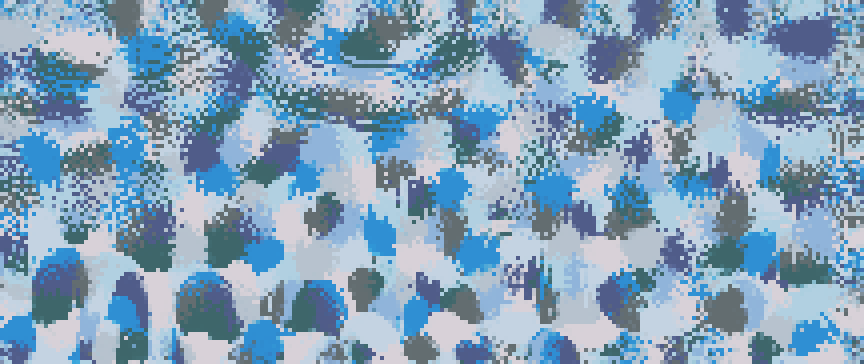

 25%|███████████████████████████████                                                                                             | 25/100 [12:46<37:55, 30.34s/it]

######################################


 26%|████████████████████████████████▏                                                                                           | 26/100 [13:15<37:14, 30.20s/it]

  EPOCH NR:  25
EPOCH LOSS:  0.8269571053220871
  DET LOSS:  0.8170710275781915
 MEAN PROB:  0.8170710275781915
   TV LOSS:  0.0
 CTRL LOSS:  0.0009061471618553425
 SEED LOSS:  0.0
 SSIM LOSS:  0.6999426458744292
EPOCH TIME:  29.86876106262207
######################################


In [ ]:
trainer = PatchTrainer(args)
trainer.train()

# Voronoi pass

Used GPU:  <NVIDIA GeForce RTX 3090 Ti on Platform: NVIDIA CUDA (2 refs)>


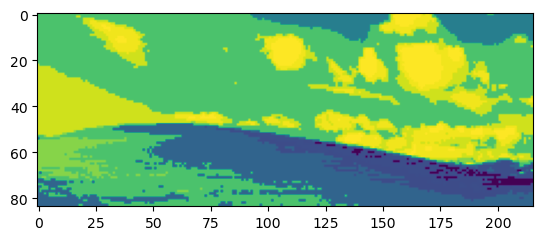

Number of objects in the image: 11.0


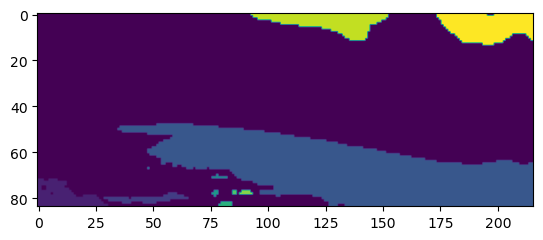

In [60]:
import pyclesperanto_prototype as cle
from skimage.io import imread, imsave
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import numpy as np
# initialize / select GPU with "TX" in their name
device = cle.select_device("TX")
print("Used GPU: ", device)

im = imread("xp.png")
im = rgb2gray(im)
plt.imshow(im)
plt.pause(0.1)
plt.cla()

# process the image
inverted = cle.subtract_image_from_scalar(im, scalar=255)
blurred = cle.gaussian_blur(inverted, sigma_x=1, sigma_y=1)
binary = cle.threshold_otsu(blurred)
labeled = cle.connected_components_labeling_box(binary)

# The maximium intensity in a label image corresponds to the number of objects
num_labels = labeled.max()
print(f"Number of objects in the image: {num_labels}")

# save image to disc
plt.imshow(labeled)

In [32]:
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
from skimage.util import img_as_float

he


/tmp/ipykernel_17835/1702379620.py:11: RuntimeWarning: Mean of empty slice.
  centroid_x.append(x.mean())
/tmp/ipykernel_17835/1702379620.py:12: RuntimeWarning: Mean of empty slice.
  centroid_y.append(y.mean())


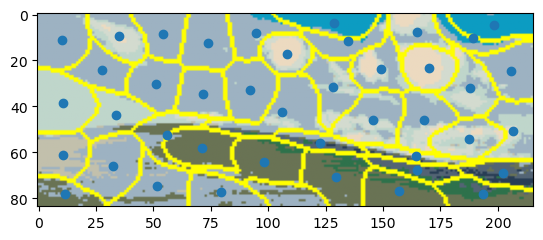

In [88]:
numSegments = 45
image = img_as_float(imread("xp.png"))
segments = slic(image, n_segments=numSegments, sigma=5, convert2lab=True)
x, y = get_centroids(segments)
# show the output of SLIC
fig = plt.figure("Superpixels -- %d segments" % (numSegments))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(mark_boundaries(image, segments))
ax.scatter(y, x)

In [163]:
# # segments.max()
from collections import defaultdict
def get_centroids(segments, img):
    centroid_x, centroid_y = [], []
    med_colors = []
    clusters = []
    grey_img = rgb2gray(img)
    
    for i in range(1, segments.max()+1):
        mask = np.where(segments==i, False, True)
        mask = np.stack([mask,mask,mask], axis=2)
        coordinates = np.argwhere(mask==False)
        x = np.array(coordinates[:, 0])
        y = np.array(coordinates[:, 1])

        centroid_x.append(x.mean())
        centroid_y.append(y.mean())

        masked_section = np.ma.array(img, mask=mask)
        color_set = defaultdict(int)
        for x in masked_section:
            for y in x:
                if not isinstance(y[0], np.ma.MaskedArray):
                    color_set[(y[0],y[1],y[2])] += 1
            
        most_seen = None
        most_seen_times = 0
        rgb_color = None
        for color in color_set:
            if color_set[color] > most_seen_times:
                most_seen = color
                most_seen_times = color_set[color]
        
        med_colors.append(most_seen)
        # break

    return centroid_x, centroid_y, med_colors

{(0.9254901960784314, 0.8549019607843137, 0.7529411764705882), (0.3254901960784314, 0.39215686274509803, 0.4549019607843137), (0.047058823529411764, 0.611764705882353, 0.7607843137254902), (0.4156862745098039, 0.45098039215686275, 0.32941176470588235), (0.8274509803921568, 0.8588235294117647, 0.8117647058823529), (0.7490196078431373, 0.8392156862745098, 0.796078431372549), (0.1803921568627451, 0.44705882352941173, 0.29411764705882354), (0.615686274509804, 0.6980392156862745, 0.7607843137254902), (0.7607843137254902, 0.7529411764705882, 0.6745098039215687)}


In [166]:
x, y, colors = get_centroids(segments, image)

In [172]:
for color in set(colors):
    print([int(color[0]*255), int(color[1]*255), int(color[2]*255)])

[236, 218, 192]
[83, 100, 116]
[12, 156, 194]
[105, 115, 84]
[211, 219, 207]
[191, 214, 203]
[46, 113, 75]
[157, 178, 194]
[194, 192, 172]


In [35]:
x = plt.imread("intermediate.png")
plt.imshow(x)

Error in callback <function _draw_all_if_interactive at 0x709e3fb82310> (for post_execute), with arguments args (),kwargs {}:


ValueError: object __array__ method not producing an array

ValueError: Output array must be a NumPy array

<Figure size 640x480 with 1 Axes>

In [36]:
x.shape

(364, 864, 4)